  departure_status  total_trips  on_time_arrivals  otp_percent
0             Late        13431                 0          0.0
1          On Time        66346             66346        100.0


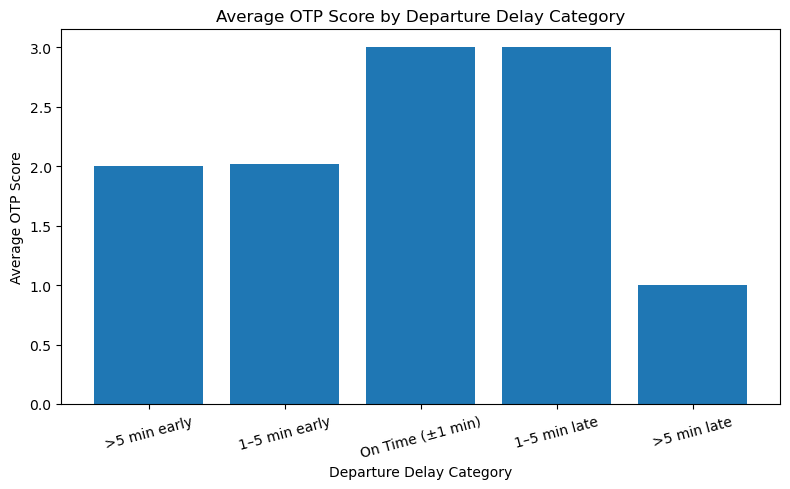


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.13      0.23      4030
           1       0.85      1.00      0.92     19904

    accuracy                           0.85     23934
   macro avg       0.93      0.57      0.58     23934
weighted avg       0.88      0.85      0.80     23934


--- Confusion Matrix ---
[[  527  3503]
 [    0 19904]]


In [1]:
# Hypothesis 1: Impact of Departure Punctuality on On-Time Performance (OTP)

# --- SETUP ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Load your cleaned stop-level data (update file path as needed)
df = pd.read_parquet("df_sample_2M.parquet")

# --- STEP 1: GET FIRST STOP PER TRIP ---
df_first_stop = df.sort_values(['SERVICE_DATE', 'TRIP_NUMBER', 'STOP_TIME']) \
                  .groupby(['SERVICE_DATE', 'TRIP_NUMBER'], as_index=False).first()

# --- STEP 2: CALCULATE DEPARTURE DELAY ---
df_first_stop['depart_delay'] = df_first_stop['LEAVE_TIME'] - df_first_stop['STOP_TIME']

# --- STEP 3: DEFINE OTP FLAG ---
df_first_stop['leave_on_time_flag'] = df_first_stop['depart_delay'].apply(lambda x: 1 if -60 <= x <= 300 else 0)
df_first_stop['is_OTP'] = df_first_stop['leave_on_time_flag']  # use this as performance outcome

# --- STEP 4: DEFINE DELAY BINS ---
df_first_stop['depart_delay_bin'] = pd.cut(
    df_first_stop['depart_delay'],
    bins=[-float('inf'), -300, -60, 60, 300, float('inf')],
    labels=['>5 min early', '1–5 min early', 'On Time (±1 min)', '1–5 min late', '>5 min late']
)

# --- STEP 5: MAP OTP SCORES FOR VISUALIZATION (OPTIONAL) ---
def assign_otp_score(delay):
    if -60 <= delay <= 300:
        return 3  # On Time
    elif delay < -60:
        return 2  # Early
    else:
        return 1  # Late


df_first_stop['otp_score'] = df_first_stop['depart_delay'].apply(assign_otp_score)

# --- STEP 6: SUMMARY TABLE ---
summary = df_first_stop.groupby('leave_on_time_flag').agg(
    total_trips=('is_OTP', 'count'),
    on_time_arrivals=('is_OTP', 'sum')
).reset_index()
summary['departure_status'] = summary['leave_on_time_flag'].map({0: 'Late', 1: 'On Time'})
summary['otp_percent'] = round(summary['on_time_arrivals'] / summary['total_trips'] * 100, 2)
summary = summary[['departure_status', 'total_trips', 'on_time_arrivals', 'otp_percent']]
print(summary)

# --- STEP 7: BAR CHART ---
avg_otp_by_bin = df_first_stop.groupby('depart_delay_bin', observed=True)['otp_score'].mean().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(avg_otp_by_bin['depart_delay_bin'], avg_otp_by_bin['otp_score'])
plt.xlabel("Departure Delay Category")
plt.ylabel("Average OTP Score")
plt.title("Average OTP Score by Departure Delay Category")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# --- STEP 8: LOGISTIC REGRESSION MODEL ---
X = df_first_stop[['depart_delay']]
y = df_first_stop['is_OTP']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))


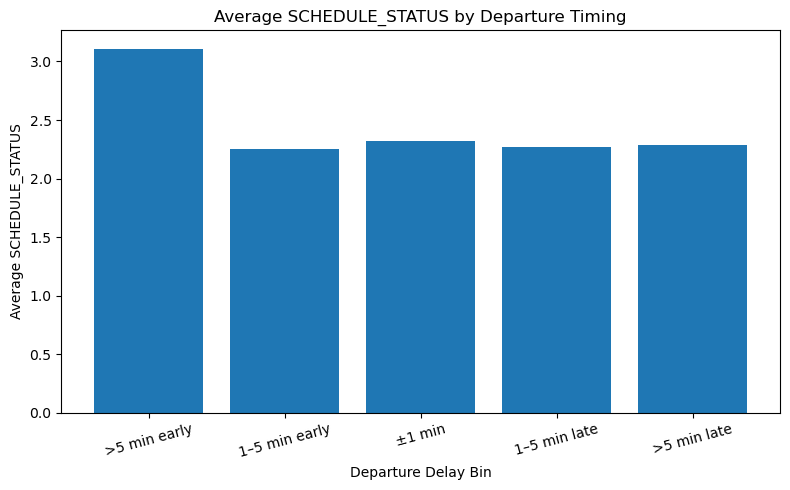

In [2]:
# Recreate departure delay
df['depart_delay'] = df['LEAVE_TIME'] - df['STOP_TIME']

# Re-bin delays if needed
df['depart_delay_bin'] = pd.cut(
    df['depart_delay'],
    bins=[-float('inf'), -300, -60, 60, 300, float('inf')],
    labels=['>5 min early', '1–5 min early', '±1 min', '1–5 min late', '>5 min late']
)

# ✅ THIS is what you want: average SCHEDULE_STATUS per delay bin
avg_status_by_bin = df.groupby('depart_delay_bin', observed=True)['SCHEDULE_STATUS'].mean().reset_index()

# Plot it
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(avg_status_by_bin['depart_delay_bin'], avg_status_by_bin['SCHEDULE_STATUS'])
plt.xlabel("Departure Delay Bin")
plt.ylabel("Average SCHEDULE_STATUS")
plt.title("Average SCHEDULE_STATUS by Departure Timing")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


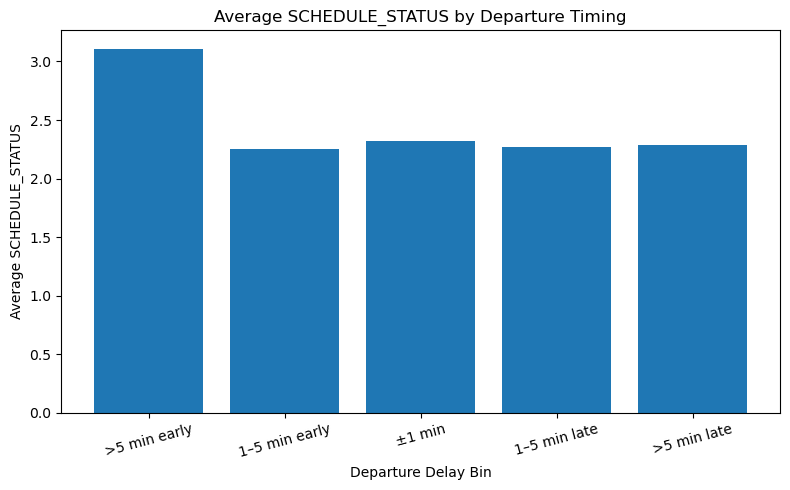

In [3]:
# Recreate departure delay
df['depart_delay'] = df['LEAVE_TIME'] - df['STOP_TIME']

# Re-bin delays if needed
df['depart_delay_bin'] = pd.cut(
    df['depart_delay'],
    bins=[-float('inf'), -300, -60, 60, 300, float('inf')],
    labels=['>5 min early', '1–5 min early', '±1 min', '1–5 min late', '>5 min late']
)

# ✅ THIS is what you want: average SCHEDULE_STATUS per delay bin
avg_status_by_bin = df.groupby('depart_delay_bin', observed=True)['SCHEDULE_STATUS'].mean().reset_index()

# Plot it
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(avg_status_by_bin['depart_delay_bin'], avg_status_by_bin['SCHEDULE_STATUS'])
plt.xlabel("Departure Delay Bin")
plt.ylabel("Average SCHEDULE_STATUS")
plt.title("Average SCHEDULE_STATUS by Departure Timing")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [4]:
df['SCHEDULE_STATUS'].value_counts().sort_index()


SCHEDULE_STATUS
0         11
2    1736148
3      44284
4     153107
5      33397
6      33053
Name: count, dtype: int64

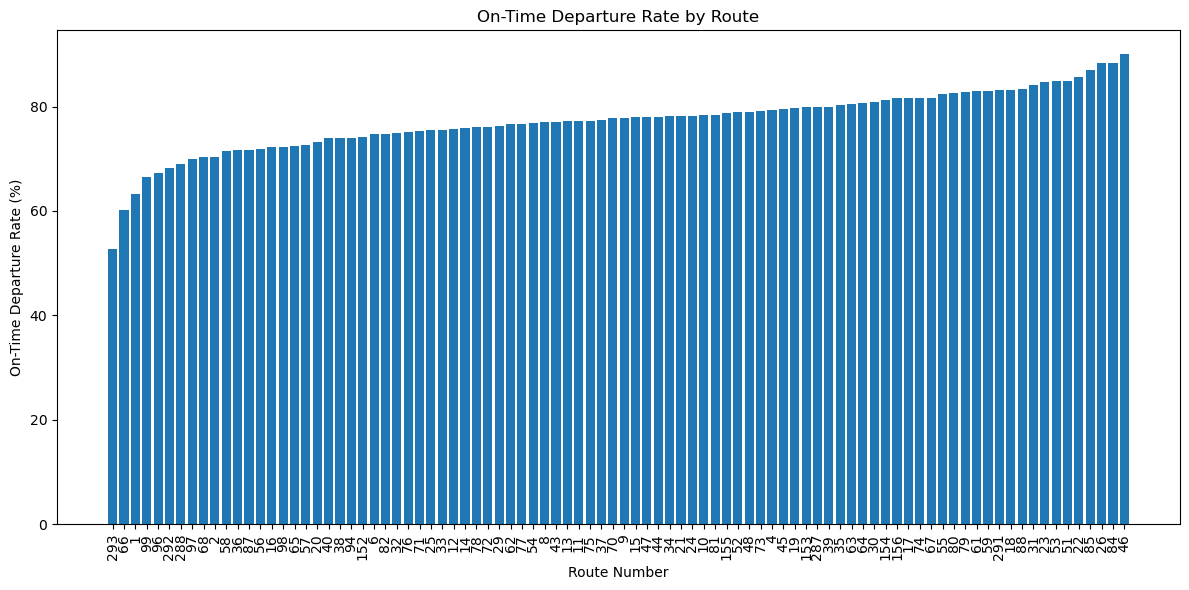

In [5]:
# Calculate percent of on-time departures per route
df['depart_delay'] = df['LEAVE_TIME'] - df['STOP_TIME']
df['on_time_departure_flag'] = df['depart_delay'].between(-60, 300)

route_punctuality = df.groupby('ROUTE_NUMBER')['on_time_departure_flag'].mean().reset_index()
route_punctuality['on_time_percent'] = route_punctuality['on_time_departure_flag'] * 100

# Sort to highlight worst-performing routes
route_punctuality = route_punctuality.sort_values(by='on_time_percent')

# Plot
plt.figure(figsize=(12, 6))
plt.bar(route_punctuality['ROUTE_NUMBER'].astype(str), route_punctuality['on_time_percent'])
plt.xlabel("Route Number")
plt.ylabel("On-Time Departure Rate (%)")
plt.title("On-Time Departure Rate by Route")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


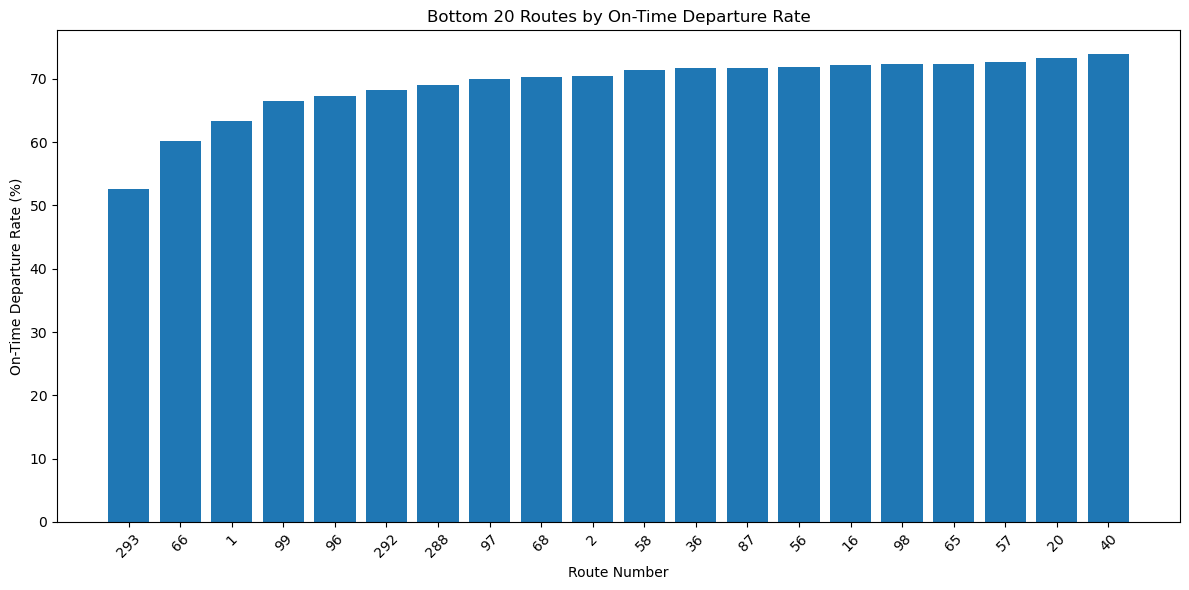

In [6]:
# Recalculate departure delay and on-time flag
df['depart_delay'] = df['LEAVE_TIME'] - df['STOP_TIME']
df['on_time_departure_flag'] = df['depart_delay'].between(-60, 300)

# Calculate on-time departure rate by route
route_punctuality = df.groupby('ROUTE_NUMBER')['on_time_departure_flag'].mean().reset_index()
route_punctuality['on_time_percent'] = route_punctuality['on_time_departure_flag'] * 100

# Filter to bottom 20 routes
lowest_20_routes = route_punctuality.sort_values(by='on_time_percent').head(20)

# Plot the graph
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(lowest_20_routes['ROUTE_NUMBER'].astype(str), lowest_20_routes['on_time_percent'])
plt.xlabel("Route Number")
plt.ylabel("On-Time Departure Rate (%)")
plt.title("Bottom 20 Routes by On-Time Departure Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [7]:
# Define departure punctuality (±1 min to +5 min = on time)
df['depart_delay'] = df['LEAVE_TIME'] - df['STOP_TIME']
df['depart_late_flag'] = df['depart_delay'] > 300  # more than 5 min late

# Define OTP at end of route (based on SCHEDULE_STATUS: on-time = 2)
df['finished_late_flag'] = df['SCHEDULE_STATUS'] > 2  # >2 means not on time

# Group by late vs. not-late departure
late_departure_groups = df.groupby('depart_late_flag')['finished_late_flag'].mean().reset_index()

# Rename for clarity
late_departure_groups.columns = ['Departed Late?', 'Finished Late Rate']
late_departure_groups['Finished Late Rate (%)'] = late_departure_groups['Finished Late Rate'] * 100

print(late_departure_groups)



   Departed Late?  Finished Late Rate  Finished Late Rate (%)
0           False            0.132002               13.200206
1            True            0.131333               13.133294


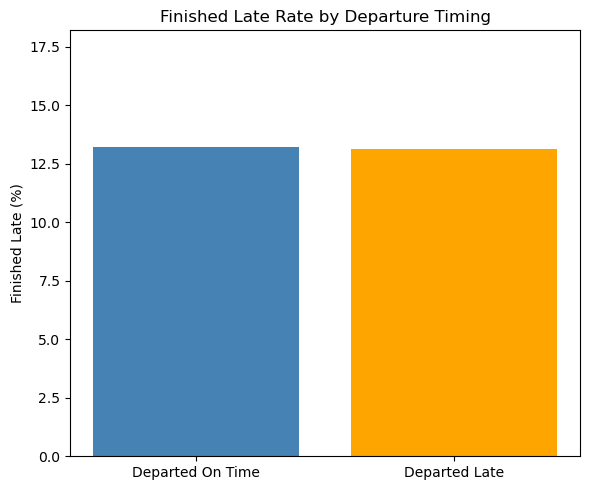

In [8]:
# Flag: departed late (>5 minutes)
df['depart_late_flag'] = df['depart_delay'] > 300

# Flag: finished late (SCHEDULE_STATUS > 2)
df['finished_late_flag'] = df['SCHEDULE_STATUS'] > 2

# Group and calculate late finish rate
late_summary = df.groupby('depart_late_flag')['finished_late_flag'].mean().reset_index()
late_summary['depart_late_flag'] = late_summary['depart_late_flag'].map({False: 'Departed On Time', True: 'Departed Late'})
late_summary['Late Finish %'] = late_summary['finished_late_flag'] * 100

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.bar(late_summary['depart_late_flag'], late_summary['Late Finish %'], color=['steelblue', 'orange'])
plt.ylabel("Finished Late (%)")
plt.title("Finished Late Rate by Departure Timing")
plt.ylim(0, max(late_summary['Late Finish %']) + 5)
plt.tight_layout()
plt.show()


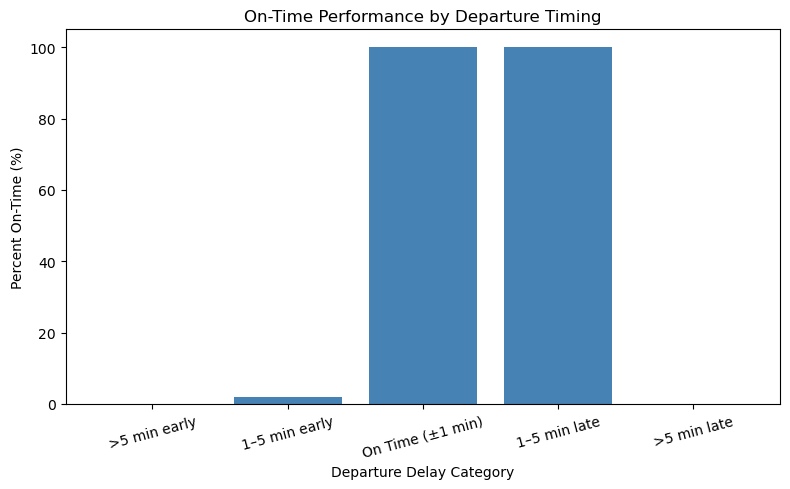

In [18]:
# Calculate real OTP percent by delay bin
otp_by_bin = df_first_stop.groupby('depart_delay_bin', observed=True)['is_OTP'].mean().reset_index()
otp_by_bin['On-Time %'] = otp_by_bin['is_OTP'] * 100

# Plot updated OTP performance
plt.figure(figsize=(8, 5))
plt.bar(otp_by_bin['depart_delay_bin'], otp_by_bin['On-Time %'], color='steelblue')
plt.xlabel("Departure Delay Category")
plt.ylabel("Percent On-Time (%)")
plt.title("On-Time Performance by Departure Timing")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [22]:
# Get first stop per trip
df_first_stop = df.sort_values(['SERVICE_DATE', 'TRIP_NUMBER', 'STOP_TIME']) \
    .groupby(['SERVICE_DATE', 'TRIP_NUMBER'], as_index=False).first()

# Calculate departure delay
df_first_stop['depart_delay'] = df_first_stop['LEAVE_TIME'] - df_first_stop['STOP_TIME']

# Real OTP flag (1 min early to 5 min late = on time)
df_first_stop['is_OTP'] = df_first_stop['depart_delay'].between(-60, 300)

# Create delay bins
df_first_stop['depart_delay_bin'] = pd.cut(
    df_first_stop['depart_delay'],
    bins=[-float('inf'), -300, -60, 60, 300, float('inf')],
    labels=['>5 min early', '1–5 min early', '±1 min', '1–5 min late', '>5 min late']
)

# Calculate on-time % per bin
otp_by_bin = df_first_stop.groupby('depart_delay_bin', observed=True)['is_OTP'].mean().reset_index()
otp_by_bin['On-Time %'] = (otp_by_bin['is_OTP'] * 100).round(2)

# Show it
otp_by_bin


,depart_delay_bin,is_OTP,On-Time %
0,>5 min early,0.000000,0.00
1,1–5 min early,0.019227,1.92
2,±1 min,1.000000,100.00
3,1–5 min late,1.000000,100.00
4,>5 min late,0.000000,0.00


In [24]:
# Calculate the percent of buses that left on time based on OTP definition
on_time_percentage = df_first_stop['is_OTP'].mean() * 100
round(on_time_percentage, 2)


83.16